In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [8]:
df = pd.read_csv("job_skills_dataset.csv")
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (2809, 22)


,Student_ID,Age,Gender,Vocational_Program,Academic_Performance,Certifications_Count,Internship_Experience,Skill_1,Skill_2,Skill_3,...,Job_ID,Job_Title,Required_Skill_1,Required_Skill_2,Required_Skill_3,Required_Skill_4,Required_Skill_5,Min_Experience_Months,Location,Job_Match
0,S0001,24,Male,Welder,51.38,2,8,8,2,5,...,J219,IT Support Technician,1,6,3,4,0,3,Pune,1
1,S0002,21,Male,Plumber,67.83,2,0,5,1,6,...,J177,Plumbing Assistant,10,9,5,6,2,2,Pune,0
2,S0003,28,Female,Mechanic,82.67,3,8,8,3,7,...,J104,Welding Operator,9,1,9,6,0,6,Pune,1
3,S0004,25,Female,Electrician,85.41,1,5,9,6,1,...,J236,Plumbing Assistant,1,2,3,4,3,3,Chennai,1
4,S0005,22,Male,IT Technician,53.47,4,3,1,7,9,...,J093,Woodwork Assistant,9,2,0,6,9,4,Mumbai,0


In [9]:
print(df.columns)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())


Index(['Student_ID', 'Age', 'Gender', 'Vocational_Program',
       'Academic_Performance', 'Certifications_Count', 'Internship_Experience',
       'Skill_1', 'Skill_2', 'Skill_3', 'Skill_4', 'Skill_5', 'Job_ID',
       'Job_Title', 'Required_Skill_1', 'Required_Skill_2', 'Required_Skill_3',
       'Required_Skill_4', 'Required_Skill_5', 'Min_Experience_Months',
       'Location', 'Job_Match'],
      dtype='object')
Missing Values: 0
Duplicate Rows: 0


In [10]:
print(df["Job_Match"].value_counts())

Job_Match
0    1918
1     891
Name: count, dtype: int64


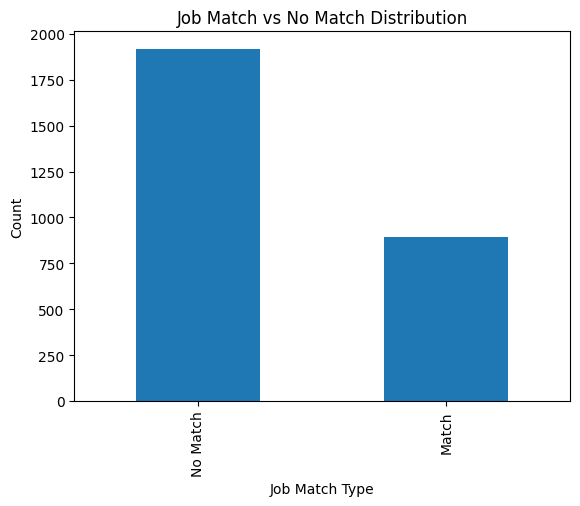

In [11]:
df["Job_Match"].value_counts().sort_index().plot(kind="bar")

plt.xticks([0, 1], ["No Match", "Match"])
plt.xlabel("Job Match Type")
plt.ylabel("Count")
plt.title("Job Match vs No Match Distribution")

plt.show()


In [12]:
skills = ["Skill_1", "Skill_2", "Skill_3", "Skill_4", "Skill_5"]
required = ["Required_Skill_1", "Required_Skill_2", "Required_Skill_3",
            "Required_Skill_4", "Required_Skill_5"]

# Skill Gap = total shortage of student skills compared to required skills
df["Skill_Gap"] = (df[required].values - df[skills].values).clip(min=0).sum(axis=1)

# Experience Check = 1 if student experience >= minimum required experience
df["Exp_Ok"] = (df["Internship_Experience"] >= df["Min_Experience_Months"]).astype(int)

df[["Skill_Gap", "Exp_Ok"]].head()


,Skill_Gap,Exp_Ok
0,4,1
1,15,0
2,3,1
3,6,1
4,10,0


In [13]:
features = ["Age", "Academic_Performance", "Certifications_Count",
            "Internship_Experience"] + skills + required + [
            "Min_Experience_Months", "Skill_Gap", "Exp_Ok"]

X = df[features]
y = df["Job_Match"]


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (2247, 17)
Testing Data: (562, 17)


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed!")


Scaling Completed!


In [16]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

print("Model Training Completed!")


Model Training Completed!


In [17]:
y_pred = model.predict(X_test_scaled)
print(y_pred[:10])


[0 0 1 0 1 0 0 1 1 0]


In [18]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")


Model Accuracy: 88.97 %


In [19]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Match", "Match"]
))


              precision    recall  f1-score   support

    No Match       0.93      0.91      0.92       384
       Match       0.82      0.84      0.83       178

    accuracy                           0.89       562
   macro avg       0.87      0.88      0.87       562
weighted avg       0.89      0.89      0.89       562



[[350  34]
 [ 28 150]]


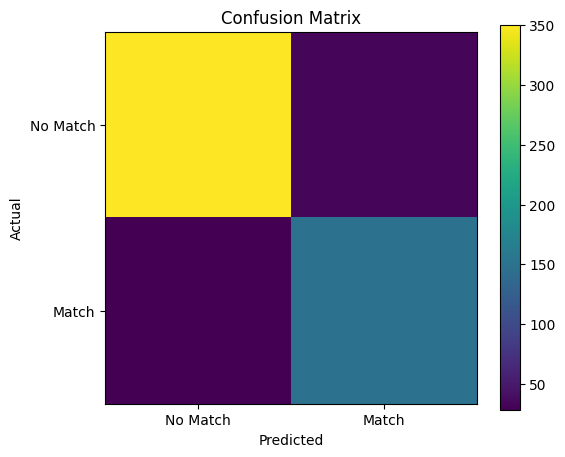

In [20]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.colorbar()
plt.xticks([0, 1], ["No Match", "Match"])
plt.yticks([0, 1], ["No Match", "Match"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [21]:
def predict_job(student_skills, job_required, internship_months,
                min_exp_months, age=23, academic=70.0, certs=2):
    gap = sum(max(r - s, 0) for s, r in zip(student_skills, job_required))
    exp_ok = 1 if internship_months >= min_exp_months else 0
    row = ([age, academic, certs, internship_months] + list(student_skills)
           + list(job_required) + [min_exp_months, gap, exp_ok])
    row_df = pd.DataFrame([row], columns=features)
    prediction = model.predict(scaler.transform(row_df))
    if prediction[0] == 1:
        return "SUITABLE FOR JOB"
    else:
        return "NOT SUITABLE FOR JOB"

# Example 1: strong candidate
result = predict_job([8, 7, 9, 8, 7], [6, 7, 8, 6, 5], 10, 6)
print("Prediction:", result)

# Example 2: weak candidate
result = predict_job([2, 1, 3, 2, 1], [8, 9, 7, 8, 9], 1, 9)
print("Prediction:", result)


Prediction: SUITABLE FOR JOB
Prediction: NOT SUITABLE FOR JOB
